## **0. Apresentação do grupo**
### Fase 1
Número do Grupo: 1
 
 - Guilherme Soares, 62372
 - Duarte Soares, 62371
 - Vitória Correia, 62211

## **1. Introdução**

Este projeto insere-se no contexto da disciplina de **Fundamentos de Aprendizagem Automática**, tendo como objetivo aplicar técnicas de **aprendizagem automática** para analisar e compreender fatores que influenciam o desempenho académico dos estudantes. Através da exploração de dados relacionados com hábitos de estudo, bem-estar e comportamento, pretende-se não só construir modelos preditivos, mas também extrair conhecimento útil que permita interpretar padrões relevantes e apoiar decisões informadas no contexto educativo.

## **1.1 Definição do problema**

O objetivo principal deste projeto é estudar a **eficiência académica** dos estudantes, procurando perceber se o sucesso académico depende apenas do número de horas de estudo ou se resulta de uma combinação mais ampla de fatores, como **capacidade de foco, qualidade do descanso, hábitos digitais e bem-estar geral**.

Esta questão é relevante porque, em contextos educativos atuais, os estudantes estão expostos a múltiplas fontes de distração e a padrões de vida que podem influenciar significativamente o seu desempenho. Assim, mais do que estudar durante mais tempo, importa compreender **que fatores estão associados a estudar melhor**.

A eficiência académica é analisada através de duas dimensões complementares:  
- **Dimensão comportamental**, relacionada com o nível de foco durante o estudo  
- **Dimensão de resultado**, refletida no desempenho obtido em avaliação  

Com base nesta perspetiva, foram definidos dois cenários preditivos complementares:

- **Cenário de Regressão:** estimar o valor de `focus_index` como **proxy do nível de concentração durante o estudo**  
- **Cenário de Classificação:** prever se um estudante pertence ao **grupo de desempenho elevado no exame**, através da variável binária `high_exam_score`, construída a partir de `exam_score`  

A variável `high_exam_score` foi definida considerando como classe positiva os estudantes cujo `exam_score` se encontra no **quartil superior da distribuição(acima do Q3)**, permitindo identificar um grupo com desempenho academicamente elevado de forma consistente com os dados observados.

Desta forma, o projeto procura responder simultaneamente a duas questões:

- **Que fatores ajudam a explicar o nível de foco de um estudante?**  
- **Com que grau de precisão é possível prever se um estudante pertence ao grupo de desempenho elevado no exame?**  

A combinação destes dois cenários permite analisar a eficiência académica de forma mais completa, relacionando não apenas o resultado final, mas também uma dimensão comportamental intermédia essencial: **o foco**.

## **1.2 Stakeholders**

Os resultados deste estudo podem ser úteis para diferentes intervenientes no contexto académico.

- **Estudantes:** podem obter informação sobre se o aumento do tempo de estudo, por si só, é suficiente para melhorar o desempenho, ou se fatores como foco, descanso e bem-estar têm um papel mais determinante  
- **Docentes, mentores e tutores:** podem utilizar estes resultados para sugerir estratégias de estudo mais eficazes e personalizadas, ajustadas aos perfis e necessidades dos estudantes  
- **Serviços de apoio ao estudante:** podem beneficiar destas conclusões para desenhar intervenções preventivas orientadas para hábitos saudáveis, equilíbrio digital e melhoria das condições de aprendizagem  
- **Coordenação académica ou instituições de ensino:** podem usar este tipo de análise para apoiar decisões relacionadas com acompanhamento pedagógico, prevenção de insucesso e promoção do bem-estar académico  

Assim, o valor do projeto não está apenas na construção de modelos preditivos, mas também na possibilidade de produzir conhecimento útil para **apoiar decisões educativas baseadas em dados** e promover estratégias de aprendizagem mais sustentáveis.

## **1.3 Imports**

Nesta secção são importadas as bibliotecas necessárias para o desenvolvimento do projeto. Estas incluem ferramentas para manipulação de dados, visualização, pré-processamento, construção de pipelines, treino de modelos e avaliação de desempenho.

In [2]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# Divisão de dados e validação
from sklearn.model_selection import train_test_split, cross_validate

# Modelos baseline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier


from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split, cross_validate, KFold, StratifiedKFold

# Display de tabelas (Jupyter)
from IPython.display import display

# Visualização de métricas
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import plot_tree


## **2. Carregamento e inspeção inicial dos dados**

Nesta fase é realizado o carregamento do dataset, a validação das variáveis-alvo definidas e a preparação dos dados para análise. É também construída a variável de classificação e efetuada uma inspeção inicial dos dados.

Importa salientar que esta etapa tem um caráter **exploratório e descritivo**. As transformações finais necessárias para modelação, como imputação, codificação e escalonamento, serão posteriormente integradas num pipeline, garantindo consistência entre treino e teste e evitando data leakage.

### **2.1 Configuração e definição de targets**

In [3]:
link = r"Dados_Projeto\student_records_missing.csv"

#estas sao as colunas que podem ser usadas como targets
allowed_cols = ["focus_index", "burnout_level", "productivity_score", "exam_score"]

# Targets definidos
target_reg = "focus_index"
target_clf_base = "exam_score"

### **2.2 Funções auxiliares para inspeção dos dados**

Foram definidas funções auxiliares para resumir a informação presente no dataset, permitindo analisar variáveis numéricas e categóricas, bem como identificar valores em falta.

In [4]:
def summarize_numeric(df):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()

    if not num_cols:
        return pd.DataFrame()

    summary = df[num_cols].agg(["count", "mean", "std", "min", "median", "max"]).T
    summary["missing"] = df[num_cols].isna().sum()

    return summary.round(3)


def summarize_categorical(df):
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    rows = []

    for col in cat_cols:
        s = df[col]
        mode = s.mode(dropna=True)

        rows.append({
            "variable": col,
            "count": s.notna().sum(),
            "missing": s.isna().sum(),
            "unique": s.nunique(dropna=True),
            "mode": mode.iloc[0] if not mode.empty else None
        })

    if rows:
        return pd.DataFrame(rows).set_index("variable")

    return pd.DataFrame()

### **2.3 Carregamento dos dados e criação das variáveis-alvo**

Nesta etapa, o dataset é carregado, são validados os targets definidos e é construída a variável de classificação.

A variável `high_exam_score` é definida com base no quartil superior de `exam_score`, sendo atribuída a classe 1 aos estudantes com desempenho elevado e 0 aos restantes.

In [5]:
def load_project_data(fname, target_reg, target_clf_base):
    df = pd.read_csv(fname)

    # Validação dos targets
    for target in [target_reg, target_clf_base]:
        if target not in allowed_cols:
            raise ValueError(f"Target inválido: {target}. Targets permitidos: {allowed_cols}")

        if target not in df.columns:
            raise ValueError(f"Target '{target}' não encontrado no dataset.")

    # Criar variável de classificação (quartil superior)
    threshold = df[target_clf_base].quantile(0.75)

    df["high_exam_score"] = (df[target_clf_base] >= threshold).astype(int)

    # Separação de features e targets
    cols_to_drop = [
        "student_id",         # identificador sem valor preditivo
        "focus_index",        # target de regressão
        "exam_score",         # base do target de classificação
        "high_exam_score",    # target de classificação
        "burnout_level",      # não usado neste problema
        "productivity_score"  # não usado neste problema
    ]

    X_raw = df.drop(columns=cols_to_drop, errors="ignore").copy()
    y_reg = df[target_reg].copy()
    y_clf = df["high_exam_score"].copy()

    return df, X_raw, y_reg, y_clf, threshold

### **2.4 Inspeção inicial dos dados**

Nesta fase é realizada uma análise descritiva do dataset, incluindo tipos de variáveis, distribuição dos dados e identificação de valores em falta.

In [6]:

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df, X_raw, y_reg, y_clf, exam_threshold = load_project_data(
    link, target_reg, target_clf_base
)

# Tabela geral com informação essencial
df_info = pd.DataFrame({
    "n_rows": [df.shape[0]],
    "n_columns": [df.shape[1]],
    "target_reg": [target_reg],
    "target_clf": ["high_exam_score"],
    "threshold": [round(exam_threshold, 3)],
    "class_0_count": [(y_clf == 0).sum()],
    "class_1_count": [(y_clf == 1).sum()],
    "class_1_ratio": [round((y_clf == 1).mean(), 3)]
})

display(df_info)

# Tabela de missing values
missing_df = pd.DataFrame({
    "missing_count": X_raw.isna().sum(),
    "missing_ratio": X_raw.isna().mean()
}).sort_values(by="missing_ratio", ascending=False)

display(missing_df)

# Resumo numérico
display(summarize_numeric(X_raw))

# Resumo categórico
cat_summary = summarize_categorical(X_raw)
if not cat_summary.empty:
    display(cat_summary)

,n_rows,n_columns,target_reg,target_clf,threshold,class_0_count,class_1_count,class_1_ratio
0,5000,22,focus_index,high_exam_score,27.4,3748,1252,0.25


,missing_count,missing_ratio
mental_health_score,750,0.15
caffeine_intake_mg,500,0.10
screen_time_hours,400,0.08
social_media_hours,250,0.05
gender,150,0.03
academic_level,100,0.02
study_hours,0,0.00
age,0,0.00
gaming_hours,0,0.00
online_classes_hours,0,0.00


,count,mean,std,min,median,max,missing
age,5000.0,20.520,2.870,16.0,20.000,25.00,0
study_hours,5000.0,4.540,1.822,0.0,4.530,11.84,0
self_study_hours,5000.0,2.479,1.178,0.0,2.480,7.41,0
online_classes_hours,5000.0,2.012,0.984,0.0,2.010,6.00,0
social_media_hours,4750.0,2.995,1.467,0.0,2.975,8.28,250
gaming_hours,5000.0,1.565,1.111,0.0,1.490,5.64,0
sleep_hours,5000.0,7.016,1.164,4.0,7.010,10.00,0
screen_time_hours,4600.0,6.986,2.476,1.0,6.955,15.30,400
exercise_minutes,5000.0,74.536,42.932,0.0,75.000,149.00,0
caffeine_intake_mg,4500.0,251.127,143.810,0.0,251.000,499.00,500


,count,missing,unique,mode
variable,,,,
gender,4850,150,3,Male
academic_level,4900,100,3,Postgraduate
internet_quality,5000,0,3,Good


## **3. Pré-processamento**

O pré-processamento foi definido com o objetivo de preparar o dataset para modelação de forma **reprodutível, consistente e metodologicamente correta**, respeitando a natureza mista das variáveis disponíveis e evitando **data leakage**.

A análise inicial dos dados mostrou a presença de:
- variáveis **numéricas** e **categóricas**
- **valores em falta** em ambos os tipos de variáveis
- diferenças de **escala** entre variáveis numéricas
- sinais de possível **assimetria** e presença de valores extremos em algumas features

Deste modo, foi construído um pipeline de pré-processamento com estratégias específicas para cada tipo de variável.

### **3.1 Justificação técnica do pré-processamento**

#### **Tratamento de valores em falta**

A análise inicial revelou a presença de valores em falta em várias variáveis, com maior incidência em `mental_health_score` (~15%), `caffeine_intake_mg` (~10%) e `screen_time_hours` (~8%).

Dado que estes valores não são negligenciáveis e que a remoção de observações implicaria perda significativa de informação, optou-se por estratégias de imputação.

Nas variáveis numéricas foi utilizada imputação pela **mediana**, uma vez que esta é robusta à presença de valores extremos. Esta decisão é suportada pela análise estatística, onde se observam amplitudes elevadas e possíveis outliers, por exemplo:
- `caffeine_intake_mg` varia entre 0 e ~500, com desvio padrão elevado (~144)
- `screen_time_hours` apresenta uma amplitude considerável (até ~15 horas)

Estas características tornam inadequado o uso da média, que é sensível a valores extremos.

Nas variáveis categóricas foi utilizada imputação pela **categoria mais frequente**, permitindo preservar a distribuição observada dos dados sem introduzir categorias artificiais.

#### **Codificação de variáveis categóricas**

As variáveis categóricas identificadas (`gender`, `academic_level` e `internet_quality`) apresentam um número reduzido de categorias distintas (3 categorias cada) e não possuem uma ordem natural.

Neste contexto, a utilização de codificação ordinal introduziria relações artificiais entre categorias (por exemplo, assumir que "Postgraduate" > "Undergraduate"), o que não é semanticamente correto.

Assim, foi utilizada codificação **One-Hot Encoding**, que transforma cada categoria numa variável binária independente, permitindo uma representação adequada das variáveis nominais.

A utilização de `drop="first"` reduz redundância entre variáveis dummy, sendo particularmente relevante para modelos lineares.


#### **Escalonamento de variáveis numéricas**

A análise estatística evidenciou diferenças significativas de escala entre variáveis numéricas, por exemplo:
- `study_hours` com valores até ~12
- `screen_time_hours` até ~15
- `caffeine_intake_mg` até ~500
- `exercise_minutes` até ~149

Adicionalmente, algumas variáveis apresentam elevada variabilidade e possíveis valores extremos, como indicado pelos desvios padrão elevados.

Dado este contexto, foi utilizado **RobustScaler**, que centra os dados na mediana e escala com base no intervalo interquartil (IQR), sendo menos sensível a outliers do que métodos baseados na média e desvio padrão.

Esta escolha é **consistente com a imputação pela mediana**, uma vez que ambas são robustas a outliers e adequadas a distribuições assimétricas, garantindo coerência no tratamento das variáveis numéricas.

Embora o escalonamento não seja essencial para modelos baseados em árvores, foi incluído no pipeline global para garantir consistência na preparação dos dados e permitir uma comparação justa entre diferentes modelos.

### **3.2 Identificação e separação das variáveis**

As variáveis foram separadas em numéricas e categóricas com base no seu tipo de dados, permitindo aplicar estratégias de pré-processamento específicas a cada grupo.

In [7]:
# Identificação dos tipos de variáveis
numeric_features = X_raw.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_raw.select_dtypes(exclude=np.number).columns.tolist()

# Tabela resumo
feature_groups_df = pd.DataFrame({
    "feature_type": ["numeric", "categorical"],
    "n_features": [len(numeric_features), len(categorical_features)]
})

display(feature_groups_df)

# Lista de variáveis numéricas
numeric_df = pd.DataFrame({"numeric_features": pd.Series(numeric_features)})
display(numeric_df)

# Lista de variáveis categóricas
categorical_df = pd.DataFrame({"categorical_features": pd.Series(categorical_features)})
display(categorical_df)

,feature_type,n_features
0,numeric,13
1,categorical,3


,numeric_features
0,age
1,study_hours
2,self_study_hours
3,online_classes_hours
4,social_media_hours
5,gaming_hours
6,sleep_hours
7,screen_time_hours
8,exercise_minutes
9,caffeine_intake_mg


,categorical_features
0,gender
1,academic_level
2,internet_quality


### **3.3 Construção do pipeline de pré-processamento**

O pipeline final foi construído com duas transformações distintas:
- um sub-pipeline para variáveis numéricas, com imputação pela mediana seguida de `RobustScaler`
- um sub-pipeline para variáveis categóricas, com imputação pela categoria mais frequente seguida de `OneHotEncoder`

Estas transformações são combinadas num `ColumnTransformer`, permitindo aplicar automaticamente o tratamento adequado a cada grupo de variáveis.

In [8]:
# Sub-pipeline numérico:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Sub-pipeline categórico:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Preprocessador global
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

### **3.4 Aplicação do pipeline para inspeção da transformação**

Nesta fase, o pipeline é aplicado apenas com o objetivo de **inspecionar o efeito das transformações** sobre os dados. Esta operação permite verificar:

- a eliminação de valores em falta
- o aumento do número de features após a codificação das variáveis categóricas
- o efeito do escalonamento sobre as variáveis numéricas

Importa salientar que, nesta fase, o pipeline é aplicado apenas para observar o efeito das transformações nos dados. Na modelação, o mesmo pipeline será integrado nos modelos, garantindo que todas as transformações são aprendidas apenas com os dados de treino, evitando data leakage.

In [9]:
# Aplicação do pipeline apenas para inspeção da transformação
X_processed = preprocessor.fit_transform(X_raw)

# Nomes das features transformadas
feature_names_out = preprocessor.get_feature_names_out()

# Conversão para DataFrame
if hasattr(X_processed, "toarray"):
    X_processed_df = pd.DataFrame(X_processed.toarray(), columns=feature_names_out)
else:
    X_processed_df = pd.DataFrame(X_processed, columns=feature_names_out)

# Tabela resumo da transformação
preprocessing_summary_df = pd.DataFrame({
    "n_features_before": [X_raw.shape[1]],
    "n_features_after": [X_processed_df.shape[1]],
    "missing_before": [int(X_raw.isna().sum().sum())],
    "missing_after": [int(X_processed_df.isna().sum().sum())]
})

display(preprocessing_summary_df)

# Resumo estatístico das variáveis numéricas após transformação
num_cols_processed = [col for col in X_processed_df.columns if col.startswith("num__")]
display(summarize_numeric(X_processed_df[num_cols_processed]))

,n_features_before,n_features_after,missing_before,missing_after
0,16,19,2150,0


,count,mean,std,min,median,max,missing
num__age,5000.0,0.104,0.574,-0.800,0.0,1.000,0
num__study_hours,5000.0,0.004,0.726,-1.805,0.0,2.912,0
num__self_study_hours,5000.0,-0.001,0.723,-1.521,0.0,3.025,0
num__online_classes_hours,5000.0,0.001,0.718,-1.467,0.0,2.912,0
num__social_media_hours,5000.0,0.010,0.749,-1.558,0.0,2.777,0
num__gaming_hours,5000.0,0.045,0.665,-0.892,0.0,2.485,0
num__sleep_hours,5000.0,0.004,0.740,-1.914,0.0,1.901,0
num__screen_time_hours,5000.0,0.009,0.759,-1.903,0.0,2.666,0
num__exercise_minutes,5000.0,-0.006,0.572,-1.000,0.0,0.987,0
num__caffeine_intake_mg,5000.0,0.001,0.623,-1.146,0.0,1.132,0


## **4. Modelos baseline**

Nesta fase foram selecionados modelos baseline simples e interpretáveis, com o objetivo de estabelecer uma referência inicial de desempenho. Estes modelos permitem avaliar o comportamento dos dados antes da utilização de abordagens mais complexas.

Para a tarefa de regressão foi utilizada a **Regressão Linear** como modelo principal, sendo complementada por uma **Árvore de Decisão** para comparação.

Para a tarefa de classificação foi utilizada a **Regressão Logística** como modelo principal, sendo igualmente considerada uma **Árvore de Decisão** como alternativa.

A escolha destes modelos deve-se ao facto de serem:
- **interpretáveis**, permitindo compreender a relação entre variáveis e target
- **simples**, servindo como ponto de partida para avaliação
- **representativos de diferentes famílias de modelos** (lineares e baseados em árvores)

Todos os modelos são treinados utilizando pipelines que integram o pré-processamento definido anteriormente, garantindo consistência entre treino e teste e evitando data leakage.

### **4.1 Divisão dos dados**

Os dados foram divididos em dois subconjuntos:
- **conjunto de treino**: utilizado para treino dos modelos e validação cruzada
- **conjunto de teste**: utilizado para avaliação do desempenho dos modelos

Na tarefa de classificação foi utilizada estratificação (`stratify=y_clf`) para preservar a distribuição das classes entre os subconjuntos.

In [10]:
RANDOM_STATE = 42

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X_raw,
    y_reg,
    y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

split_df = pd.DataFrame({
    "dataset": ["train", "test"],
    "n_samples": [X_train.shape[0], X_test.shape[0]]
})

display(split_df)

,dataset,n_samples
0,train,4000
1,test,1000


### **4.2 Definição dos modelos baseline**

Os modelos foram definidos através de pipelines que integram o pré-processamento com o algoritmo de aprendizagem, garantindo que todas as transformações são aplicadas corretamente em cada fase do treino e avaliação.

Para os modelos de classificação foi utilizado `class_weight="balanced"`, de forma a compensar o desbalanceamento entre classes, atribuindo maior peso à classe minoritária e evitando que o modelo favoreça excessivamente a classe dominante.

Nas árvores de decisão foi fixada uma profundidade máxima de 5 nesta fase inicial, de forma a controlar a complexidade do modelo e reduzir o risco de sobreajuste, mantendo ainda assim interpretabilidade.

In [11]:

# Regressão
reg_models = {
    "LinearRegression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "DecisionTreeRegressor": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=RANDOM_STATE,
            max_depth=5
        ))
    ])
}

# Classificação
clf_models = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]),
    "DecisionTreeClassifier": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=5,
            class_weight="balanced"
        ))
    ])
}

### **4.3 Métricas de avaliação**

Foram definidas métricas adequadas a cada tipo de problema, distinguindo entre uma **métrica primária**, utilizada como principal critério de comparação entre modelos, e uma **métrica secundária**, utilizada para complementar a análise.

#### **Regressão**

Na tarefa de regressão foi definida como métrica primária o **RMSE (Root Mean Squared Error)**. Esta métrica penaliza mais fortemente erros elevados, sendo particularmente adequada neste contexto, onde grandes desvios na previsão do `focus_index` representam previsões significativamente incorretas.

Como métrica secundária foi utilizado o **R² (coeficiente de determinação)**, que mede a proporção da variância da variável alvo explicada pelo modelo. Esta métrica permite avaliar a qualidade global do ajuste e complementar a interpretação do RMSE.

#### **Classificação**

Na tarefa de classificação foi definido como métrica primária o **F1-score**, uma vez que combina precisão e recall numa única métrica. Esta escolha é adequada devido ao desbalanceamento entre classes (~25% classe positiva), tornando a accuracy isolada potencialmente enganadora.

Como métrica secundária foi utilizada a **ROC-AUC**, que avalia a capacidade do modelo em distinguir entre classes de forma independente do threshold de decisão. Esta métrica complementa o F1-score porque permite avaliar a capacidade discriminativa do modelo mesmo quando o threshold de classificação não é ótimo.

Como métrica complementar foi mantida a **accuracy**, por fornecer uma leitura global simples da proporção de previsões corretas. No entanto, esta métrica não foi usada como principal critério de comparação, devido ao desbalanceamento entre classes.

In [12]:
def evaluate_regression(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)

    return {
        "model": model_name,
        "rmse_test": rmse_test,
        "r2_test": r2_test
    }


def evaluate_classification(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    return {
        "model": model_name,
        "f1": f1_score(y_test, y_pred_test, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob_test),
        "accuracy": accuracy_score(y_test, y_pred_test)
    }

### **4.4 Treino e avaliação dos modelos**

Os modelos foram treinados e avaliados nos conjuntos de treino e teste, sendo os resultados apresentados sob a forma de tabelas comparativas.

In [13]:
# Regressão
reg_results = []
for name, model in reg_models.items():
    reg_results.append(
        evaluate_regression(model, X_train, X_test, y_train_reg, y_test_reg, name)
    )

reg_results_df = pd.DataFrame(reg_results).sort_values(by="rmse_test")

display(reg_results_df)


# Classificação
clf_results = []
for name, model in clf_models.items():
    clf_results.append(
        evaluate_classification(model, X_train, X_test, y_train_clf, y_test_clf, name)
    )

clf_results_df = pd.DataFrame(clf_results).sort_values(by="f1", ascending=False)

clf_results_df = clf_results_df[[
    "model",
    "f1",
    "roc_auc",
    "accuracy"
]]

display(clf_results_df)

,model,rmse_test,r2_test
0,LinearRegression,5.527448,0.692212
1,DecisionTreeRegressor,7.054088,0.498716


,model,f1,roc_auc,accuracy
0,LogisticRegression,0.729373,0.922347,0.836
1,DecisionTreeClassifier,0.615883,0.834328,0.763


### **4.5 Validação cruzada**

Para garantir a robustez dos resultados, foi utilizada validação cruzada sobre o conjunto de treino, complementando a avaliação realizada no conjunto de teste.

Na tarefa de regressão foi utilizado `KFold`, enquanto na classificação foi utilizado `StratifiedKFold`, de forma a preservar a proporção das classes em cada fold.

Esta abordagem permite obter estimativas mais estáveis do desempenho dos modelos e avaliar a consistência dos resultados face a diferentes divisões dos dados.

In [14]:
kf_reg = KFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)
skf_clf = StratifiedKFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)

reg_scoring = {
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

clf_scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

# -------------------------
# Regressão
# -------------------------
cv_reg_results = []

for name, model in reg_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train_reg,
        cv=kf_reg,
        scoring=reg_scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_reg_results.append({
        "model": name,
        "cv_rmse_train_mean": -scores["train_rmse"].mean(),
        "cv_rmse_test_mean": -scores["test_rmse"].mean(),
        "cv_r2_train_mean": scores["train_r2"].mean(),
        "cv_r2_test_mean": scores["test_r2"].mean(),
        "cv_rmse_test_std": scores["test_rmse"].std(),
        "cv_r2_test_std": scores["test_r2"].std()
    })

cv_reg_df = pd.DataFrame(cv_reg_results).sort_values(by="cv_rmse_test_mean")
display(cv_reg_df[[
    "model",
    "cv_rmse_test_mean",
    "cv_r2_test_mean",
    "cv_rmse_test_std",
    "cv_r2_test_std"
]])

# -------------------------
# Classificação
# -------------------------
cv_clf_results = []

for name, model in clf_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train_clf,
        cv=skf_clf,
        scoring=clf_scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_clf_results.append({
    "model": name,

    "cv_f1_train_mean": scores["train_f1"].mean(),
    "cv_f1_test_mean": scores["test_f1"].mean(),

    "cv_roc_auc_train_mean": scores["train_roc_auc"].mean(),
    "cv_roc_auc_test_mean": scores["test_roc_auc"].mean(),

    "cv_accuracy_train_mean": scores["train_accuracy"].mean(),
    "cv_accuracy_test_mean": scores["test_accuracy"].mean(),

    "cv_f1_test_std": scores["test_f1"].std(),
    "cv_roc_auc_test_std": scores["test_roc_auc"].std(),
    "cv_accuracy_test_std": scores["test_accuracy"].std()
})

cv_clf_df = pd.DataFrame(cv_clf_results).sort_values(by="cv_f1_test_mean", ascending=False)
display(cv_clf_df[[
    "model",
    "cv_f1_test_mean",
    "cv_roc_auc_test_mean",
    "cv_accuracy_test_mean",
    "cv_f1_test_std",
    "cv_roc_auc_test_std",
    "cv_accuracy_test_std"
]])

,model,cv_rmse_test_mean,cv_r2_test_mean,cv_rmse_test_std,cv_r2_test_std
0,LinearRegression,5.599146,0.680882,0.222937,0.029975
1,DecisionTreeRegressor,7.235252,0.468242,0.241742,0.032719


,model,cv_f1_test_mean,cv_roc_auc_test_mean,cv_accuracy_test_mean,cv_f1_test_std,cv_roc_auc_test_std,cv_accuracy_test_std
0,LogisticRegression,0.712907,0.922026,0.829741,0.022397,0.011331,0.013913
1,DecisionTreeClassifier,0.646482,0.844063,0.791486,0.039039,0.028638,0.027531



### **4.5.1 Comparação entre conjunto de teste e validação cruzada**

De forma a avaliar a consistência dos resultados, foi realizada uma comparação direta entre o desempenho obtido no conjunto de teste (one split) e os resultados médios da validação cruzada.

Esta comparação permite verificar se os resultados obtidos não dependem de uma divisão específica dos dados, reforçando a fiabilidade das conclusões.

In [15]:
# -------------------------
# Regressão
# -------------------------
reg_compare_df = reg_results_df.merge(
    cv_reg_df[["model", "cv_rmse_test_mean", "cv_r2_test_mean"]],
    on="model",
    how="left"
)

# Reordenar colunas (intercalado)
reg_compare_df = reg_compare_df.rename(columns={
    "rmse_test": "RMSE (Test)",
    "cv_rmse_test_mean": "RMSE (CV)",
    "r2_test": "R² (Test)",
    "cv_r2_test_mean": "R² (CV)"
})

display(reg_compare_df)

# -------------------------
# Classificação
# -------------------------
clf_compare_df = clf_results_df.merge(
    cv_clf_df[[
        "model",
        "cv_f1_test_mean",
        "cv_roc_auc_test_mean",
        "cv_accuracy_test_mean"
    ]],
    on="model",
    how="left"
)

clf_compare_df = clf_compare_df[[
    "model",
    "f1", "cv_f1_test_mean",
    "roc_auc", "cv_roc_auc_test_mean",
    "accuracy", "cv_accuracy_test_mean"
]]

# Reordenar colunas (intercalado)
clf_compare_df = clf_compare_df.rename(columns={
    "f1": "F1-score (Test)",
    "cv_f1_test_mean": "F1-score (CV)",
    "roc_auc": "ROC-AUC (Test)",
    "cv_roc_auc_test_mean": "ROC-AUC (CV)",
    "accuracy": "Accuracy (Test)",
    "cv_accuracy_test_mean": "Accuracy (CV)"
})

display(clf_compare_df)

,model,RMSE (Test),R² (Test),RMSE (CV),R² (CV)
0,LinearRegression,5.527448,0.692212,5.599146,0.680882
1,DecisionTreeRegressor,7.054088,0.498716,7.235252,0.468242


,model,F1-score (Test),F1-score (CV),ROC-AUC (Test),ROC-AUC (CV),Accuracy (Test),Accuracy (CV)
0,LogisticRegression,0.729373,0.712907,0.922347,0.922026,0.836,0.829741
1,DecisionTreeClassifier,0.615883,0.646482,0.834328,0.844063,0.763,0.791486


<a id="462-coeficientes-regressao-logistica"></a>\
### **4.5.2 Interpretação dos resultados**

Os resultados obtidos através de validação cruzada permitem tirar conclusões consistentes sobre o desempenho e a capacidade de generalização dos modelos, com base nas métricas definidas previamente.

Na tarefa de regressão, a Regressão Linear apresenta melhor desempenho segundo a métrica principal, o **RMSE**, evidenciando erros médios inferiores em comparação com a Árvore de Decisão. Adicionalmente, o valor mais elevado de **R²** indica uma maior capacidade explicativa do modelo, sendo capaz de capturar aproximadamente 68–69% da variabilidade da variável `focus_index`. A proximidade entre os valores de treino e validação cruzada em ambas as métricas sugere boa capacidade de generalização e ausência de overfitting.

Por outro lado, a Árvore de Decisão apresenta um **RMSE superior** e um **R² inferior**, indicando pior desempenho tanto ao nível do erro como da capacidade explicativa. A diferença mais acentuada entre treino e validação indicando sinais ligeiros de overfitting, sugerindo **menor capacidade de generalização**.

Na tarefa de classificação, a Regressão Logística apresenta melhor desempenho segundo a métrica principal, o **F1-score**, indicando um bom equilíbrio entre precisão e recall. A métrica secundária, **ROC-AUC**, apresenta também valores elevados, indicando uma forte capacidade de distinção entre classes e uma boa ordenação das observações segundo a probabilidade de pertencerem à classe positiva.

A diferença entre o **ROC-AUC** elevado (~0.92) e o **F1-score** mais moderado (~0.71) indica que, embora o modelo tenha uma forte capacidade discriminativa, o threshold de decisão utilizado na classificação binária ainda não é ótimo, resultando em alguns erros de classificação. A **accuracy**, utilizada como métrica complementar, fornece uma leitura global da proporção de previsões corretas, mas não é usada como principal critério de comparação devido ao desbalanceamento entre classes.

A reduzida variabilidade do **F1-score** entre folds confirma a estabilidade do modelo, indicando que o seu desempenho é consistente face a diferentes divisões dos dados.

A Árvore de Decisão apresenta valores inferiores tanto de **F1-score** como de **ROC-AUC**, indicando pior desempenho na tarefa de classificação e menor capacidade discriminativa entre classes. A **accuracy**, enquanto métrica complementar, confirma também um desempenho global inferior. Apesar de apresentar alguma estabilidade, o modelo revela-se globalmente menos eficaz.

De forma geral, considerando as métricas principais, secundárias e complementares definidas, os modelos lineares (Regressão Linear e Regressão Logística) demonstram melhor desempenho e maior capacidade de generalização nesta fase do projeto. Na classificação, o **F1-score** sustenta a escolha da Regressão Logística como melhor baseline, enquanto o **ROC-AUC** reforça a sua superior capacidade discriminativa.

### **4.6 Representações gráficas dos modelos**

Para complementar a avaliação quantitativa dos modelos baseline, são apresentadas algumas representações gráficas que permitem interpretar melhor o comportamento dos modelos e a forma como utilizam as variáveis disponíveis.

Nesta fase, são mostradas:
- a **matriz de confusão** da Regressão Logística, por ser o melhor baseline de classificação
- o **gráfico dos coeficientes** da Regressão Logística
- uma **visualização simplificada da Árvore de Decisão para classificação**
- o **gráfico dos coeficientes** da Regressão Linear

#### **4.6.1 Matriz de confusão - Regressão Logística**

A matriz de confusão permite visualizar o número de classificações corretas e incorretas em cada classe, complementando métricas como F1-score, ROC-AUC e accuracy.

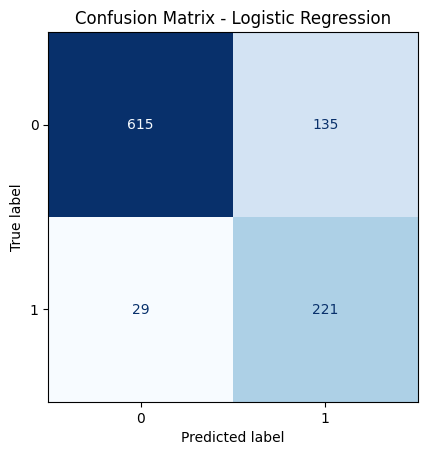

In [16]:
# Treino do modelo logístico
log_model = clf_models["LogisticRegression"]
log_model.fit(X_train, y_train_clf)

# Previsões no conjunto de teste
y_pred_log = log_model.predict(X_test)

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    y_pred_log,
    cmap="Blues",
    colorbar=False
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

A matriz de confusão mostra que o modelo reduz os falsos negativos (29), identificando a maioria dos estudantes com desempenho elevado, mas aumenta os falsos positivos (135). Este efeito está associado ao `class_weight="balanced"`, favorecendo o recall e o F1-score, embora prejudique a precisão e a accuracy. 


### 4.6.2 Coeficientes - Regressão Logística

Na Regressão Logística, os coeficientes representam o efeito das variáveis no log-odds da classe positiva (`high_exam_score = 1`). Coeficientes positivos estão associados a um aumento da probabilidade prevista de desempenho elevado, enquanto coeficientes negativos indicam o efeito oposto.

,feature,coefficient,abs_coefficient
12,num__mental_health_score,3.263903,3.263903
1,num__study_hours,2.446864,2.446864
11,num__upcoming_deadline,-1.428927,1.428927
6,num__sleep_hours,1.204831,1.204831
10,num__part_time_job,-0.919474,0.919474
4,num__social_media_hours,-0.540719,0.540719
7,num__screen_time_hours,-0.458556,0.458556
8,num__exercise_minutes,0.333295,0.333295
2,num__self_study_hours,0.324237,0.324237
5,num__gaming_hours,-0.300927,0.300927


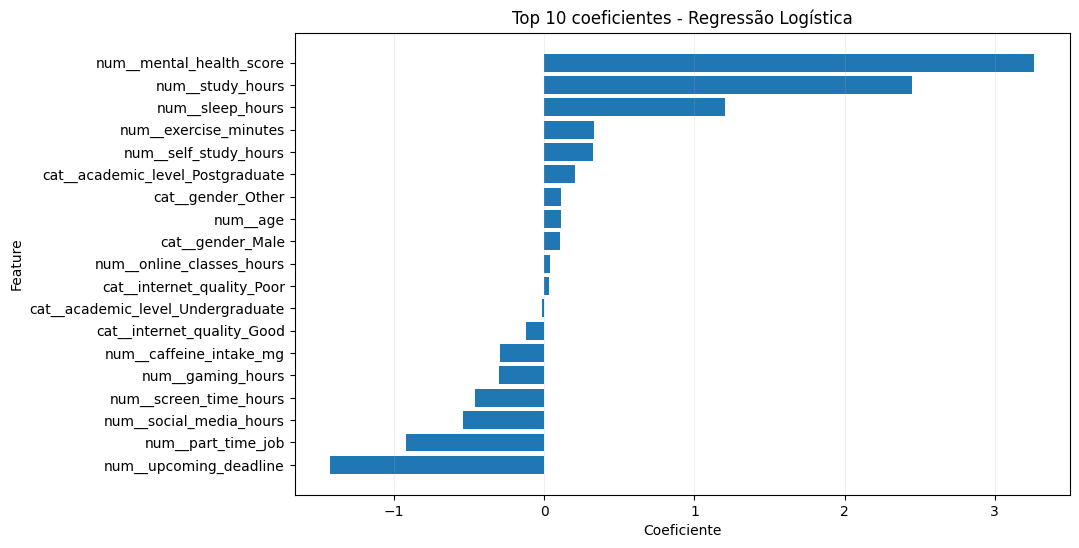

In [18]:
# Extração dos coeficientes
log_features = log_model.named_steps["preprocessor"].get_feature_names_out()
log_coefs = log_model.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "feature": log_features,
    "coefficient": log_coefs,
    "abs_coefficient": np.abs(log_coefs)
}).sort_values(by="abs_coefficient", ascending=False)

display(log_coef_df.head(15))

# Gráfico dos coeficientes mais influentes
top_log = log_coef_df.head(len(log_coef_df)).sort_values(by="coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_log["feature"], top_log["coefficient"])
plt.xlabel("Coeficiente")
plt.ylabel("Feature")
plt.title("Top 10 coeficientes - Regressão Logística")
plt.grid(axis="x", alpha=0.2)
plt.show()

O gráfico mostra que variáveis como `mental_health_score`, `study_hours` e `sleep_hours` têm maior influência positiva na probabilidade de desempenho elevado, enquanto fatores como `upcoming_deadline`, `part_time_job` e tempo de distração (`social_media_hours`, `screen_time_hours`, `gaming_hours`) estão associados a uma redução dessa probabilidade, contribuindo para a interpretação do modelo que suporta o bom desempenho observado nas métricas **(ROC-AUC e F1-score).**

#### **4.6.3 Visualização da Árvore de Decisão para Classificação**

A árvore de decisão permite uma representação visual direta das regras utilizadas pelo modelo para separar as classes. Para manter a legibilidade, a visualização foi limitada aos primeiros níveis da árvore.

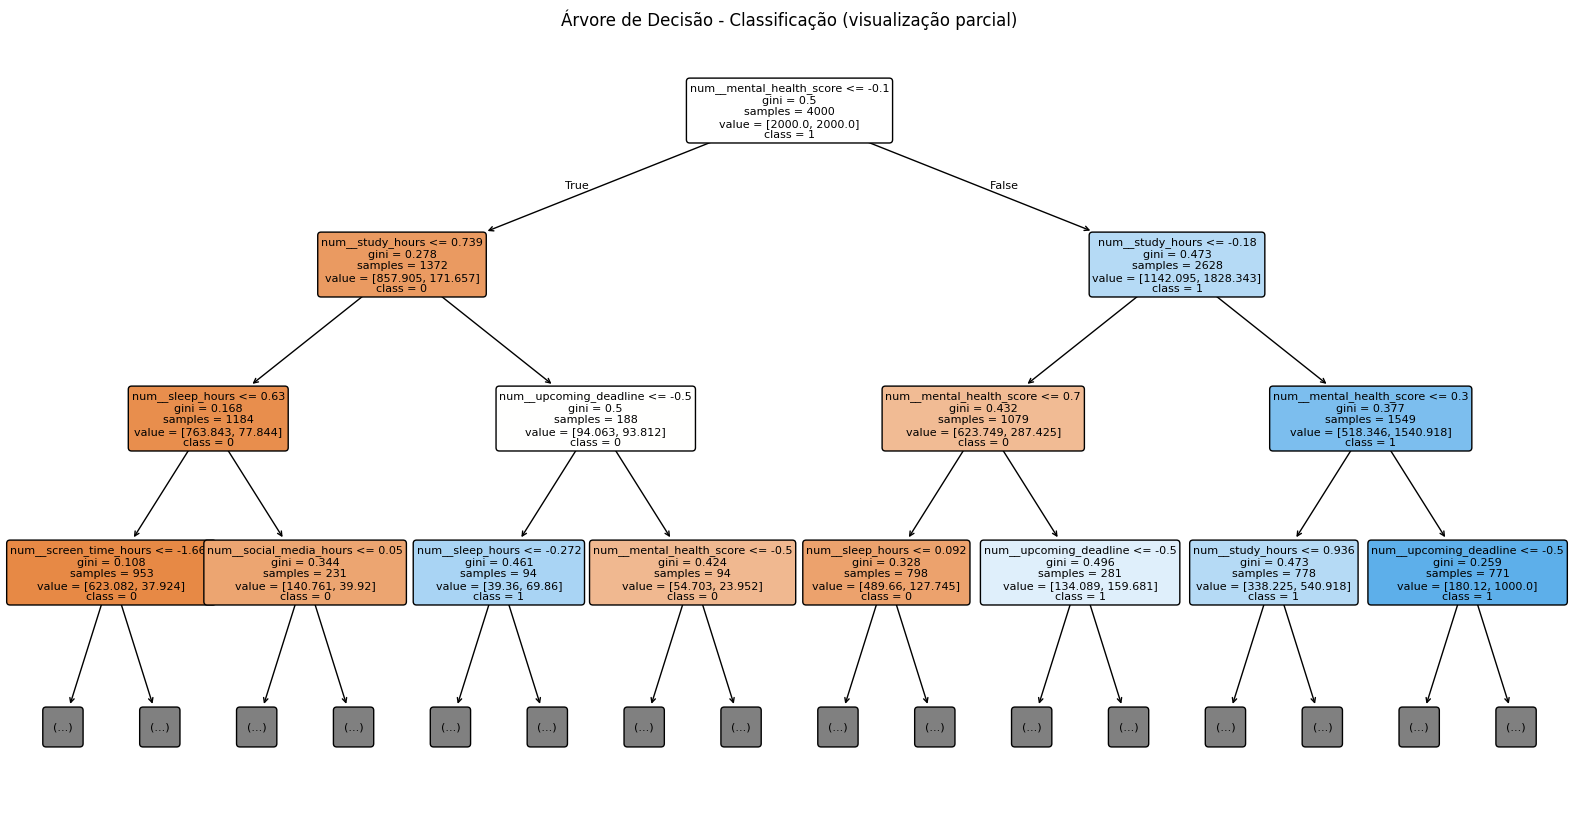

In [19]:
# Treino da árvore de classificação
dt_clf_model = clf_models["DecisionTreeClassifier"]
dt_clf_model.fit(X_train, y_train_clf)

# Extração do estimador e nomes das features
dt_clf_estimator = dt_clf_model.named_steps["model"]
dt_clf_features = dt_clf_model.named_steps["preprocessor"].get_feature_names_out()

# Visualização parcial da árvore
plt.figure(figsize=(20, 10)) #por (70,10) caso queira visualizar a arvore toda
plot_tree(
    dt_clf_estimator,
    feature_names=dt_clf_features,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árvore de Decisão - Classificação (visualização parcial)")
plt.show()

A árvore de decisão mostra que variáveis como `mental_health_score` e `study_hours` surgem nos primeiros níveis de decisão, indicando forte importância na separação das classes. No entanto, a presença de várias divisões sucessivas e nós com menor pureza sugere que o modelo captura padrões mais específicos dos dados, o que está alinhado com o desempenho inferior nas métricas **(F1-score e ROC-AUC)** e com sinais de **menor capacidade de generalização face à Regressão Logística.**

#### **4.6.4 Coeficientes - Regressão Linear**

Na Regressão Linear, os coeficientes indicam a direção e magnitude da associação entre cada variável e o valor previsto de `focus_index`. Coeficientes positivos indicam associação direta com o foco, enquanto coeficientes negativos indicam associação inversa.

,feature,coefficient,abs_coefficient
12,num__mental_health_score,9.855409,9.855409
1,num__study_hours,6.381992,6.381992
4,num__social_media_hours,-3.952030,3.952030
2,num__self_study_hours,3.096844,3.096844
5,num__gaming_hours,-2.638262,2.638262
6,num__sleep_hours,2.270612,2.270612
17,cat__internet_quality_Good,-0.441090,0.441090
13,cat__gender_Male,-0.218950,0.218950
0,num__age,-0.208410,0.208410
8,num__exercise_minutes,-0.178965,0.178965


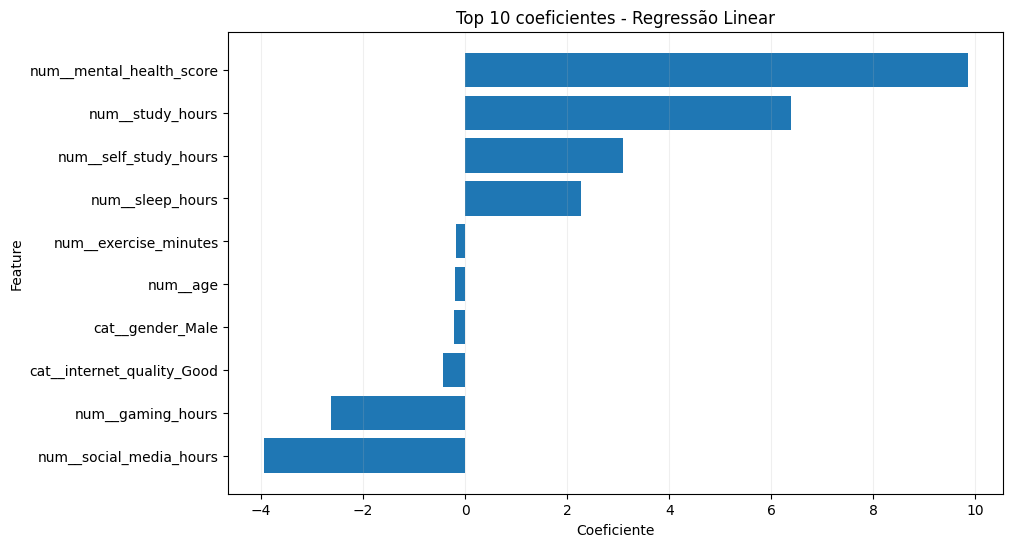

In [20]:
# Treino do modelo linear
lin_model = reg_models["LinearRegression"]
lin_model.fit(X_train, y_train_reg)

# Extração dos coeficientes
lin_features = lin_model.named_steps["preprocessor"].get_feature_names_out()
lin_coefs = lin_model.named_steps["model"].coef_

lin_coef_df = pd.DataFrame({
    "feature": lin_features,
    "coefficient": lin_coefs,
    "abs_coefficient": np.abs(lin_coefs)
}).sort_values(by="abs_coefficient", ascending=False)

display(lin_coef_df.head(10))

# Gráfico dos coeficientes mais influentes
top_lin = lin_coef_df.head(10).sort_values(by="coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_lin["feature"], top_lin["coefficient"])
plt.xlabel("Coeficiente")
plt.ylabel("Feature")
plt.title("Top 10 coeficientes - Regressão Linear")
plt.grid(axis="x", alpha=0.2)
plt.show()

O gráfico mostra que variáveis como `mental_health_score` e `study_hours` têm maior impacto positivo na previsão do nível de foco, seguidas por `self_study_hours` e `sleep_hours`, enquanto fatores associados a distração, como `social_media_hours` e `gaming_hours`, apresentam impacto negativo. Estes resultados são consistentes com o bom desempenho do modelo de regressão (baixo RMSE e R² elevado), indicando que o modelo consegue captar relações relevantes entre hábitos dos estudantes e o nível de foco.

### **4.7 Análise de erro**

Para complementar a avaliação dos modelos, foi realizada uma análise de erro com o objetivo de identificar padrões associados às previsões incorretas.

Esta análise permite ir além das métricas globais, inspecionando casos específicos onde o modelo falha, contribuindo para uma melhor compreensão das suas limitações.

Na **regressão**, foram analisadas as observações com **maior erro absoluto entre o valor real e o valor previsto.**

Na **classificação**, foram **inspecionados os casos em que o modelo erra a classe, distinguindo entre falsos positivos e falsos negativos.**

Esta abordagem permite identificar potenciais causas para o erro, como:
- presença de outliers
- relações não lineares não captadas pelos modelos
- observações próximas do threshold de decisão
- ausência de variáveis explicativas relevantes

#### **4.7.1 Análise de erro na regressão**

In [21]:
# Usar o modelo linear como referência
reg_model = reg_models["LinearRegression"]
reg_model.fit(X_train, y_train_reg)

y_pred_reg = reg_model.predict(X_test)

# Cálculo do erro absoluto
errors_reg = np.abs(y_test_reg - y_pred_reg)

error_reg_df = pd.DataFrame({
    "real": y_test_reg,
    "pred": y_pred_reg,
    "abs_error": errors_reg
}).sort_values(by="abs_error", ascending=False)

# Top 10 maiores erros
display(error_reg_df.head(10))

# Features associadas aos maiores erros
X_test_errors_reg = X_test.loc[error_reg_df.head(5).index]
display(X_test_errors_reg)

,real,pred,abs_error
4633,57.73,36.130981,21.599019
709,45.57,26.211891,19.358109
4864,1.52,20.666556,19.146556
3005,52.20,33.147191,19.052809
2840,5.04,23.964143,18.924143
4797,16.36,34.843541,18.483541
4402,46.11,27.635684,18.474316
581,52.29,36.321855,15.968145
3882,60.06,44.525996,15.534004
4665,30.97,15.568641,15.401359


,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score
4633,24,Male,High School,6.45,3.67,0.46,1.33,2.36,6.07,4.39,130,312.0,0,1,Average,NaN
709,20,Male,Undergraduate,7.34,1.47,4.07,5.82,2.24,6.88,9.14,11,395.0,0,1,Good,NaN
4864,19,Other,Undergraduate,3.07,2.79,3.98,4.69,1.99,7.01,1.00,75,495.0,0,1,Good,NaN
3005,18,Female,Postgraduate,5.18,4.47,2.68,1.28,3.78,6.31,7.75,85,39.0,1,1,Good,NaN
2840,25,Male,Undergraduate,4.06,0.62,0.62,2.39,1.39,6.47,7.34,138,417.0,1,1,Average,NaN


Na análise dos casos com maior erro absoluto, observa-se que o modelo apresenta dificuldades em prever corretamente valores extremos da variável `focus_index`, tanto em situações de foco muito elevado como muito reduzido.

Estes erros refletem limitações do modelo linear, que assume relações lineares entre as variáveis explicativas e o target, não captando adequadamente padrões mais complexos ou interações entre variáveis.

Adicionalmente, verifica-se que várias observações com elevado erro apresentam valores em falta na variável `mental_health_score`. **Apesar da imputação pela mediana mitigar a ausência de dados, esta estratégia pode reduzir a variabilidade e eliminar informação relevante**, contribuindo para previsões menos precisas.

Observam-se também perfis com combinações potencialmente contraditórias, como níveis relativamente elevados de estudo coexistindo com elevados níveis de distração (por exemplo, `social_media_hours` e `screen_time_hours`). Estes casos sugerem a **existência de relações não lineares ou efeitos de interação que não são captados por modelos lineares simples.**

Por fim, nota-se que alguns erros elevados ocorrem em **observações com valores extremos ou pouco frequentes nas features** (por exemplo, níveis muito elevados de consumo de cafeína ou exercício), indicando que o modelo tem **menor capacidade de generalização** nessas regiões do espaço de dados.

De forma geral, estes resultados indicam que **modelos mais flexíveis**, capazes de capturar não linearidades e interações entre variáveis, **poderão melhorar o desempenho em fases posteriores do projeto.**

#### **4.7.2 Análise de erro na classificação**

Foram analisadas as previsões incorretas no conjunto de teste, distinguindo entre diferentes tipos de erro.

Esta análise permite compreender em que situações o modelo falha na distinção entre estudantes com desempenho elevado e os restantes.

In [22]:
# Usar logistic regression como referência
clf_model = clf_models["LogisticRegression"]
clf_model.fit(X_train, y_train_clf)

y_pred_clf = clf_model.predict(X_test)

# DataFrame com erros
error_clf_df = pd.DataFrame({
    "real": y_test_clf,
    "pred": y_pred_clf
})

# Filtrar apenas erros
errors_only_df = error_clf_df[error_clf_df["real"] != error_clf_df["pred"]]

display(errors_only_df.head(10))

# Features dos casos com erro
X_test_errors_clf = X_test.loc[errors_only_df.head(5).index]
display(X_test_errors_clf)

,real,pred
3636,0,1
4034,0,1
3451,0,1
793,0,1
3634,0,1
3390,0,1
2148,0,1
1244,1,0
4511,0,1
4290,0,1


,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score
3636,17,NaN,Postgraduate,4.76,4.11,2.58,2.54,1.35,6.85,7.77,39,52.0,1,1,Poor,9.0
4034,23,Other,Undergraduate,4.44,1.05,0.74,4.00,1.79,6.26,9.11,124,47.0,0,1,Average,10.0
3451,17,Female,High School,5.84,1.59,2.69,4.69,0.81,6.98,3.31,127,83.0,1,1,Poor,9.0
793,21,Male,Undergraduate,4.70,3.07,2.54,3.97,1.49,8.73,6.50,57,174.0,0,0,Poor,4.0
3634,23,Female,Postgraduate,5.30,2.85,0.97,3.76,1.19,6.88,NaN,105,373.0,0,0,Poor,10.0


A análise dos erros de classificação evidencia uma predominância de **falsos positivos**, ou seja, casos em que o modelo prevê desempenho elevado quando, na realidade, o estudante não pertence à classe positiva.

Este comportamento está associado a um recall elevado, indicando que o modelo consegue identificar a maioria dos casos positivos, reduzindo o número de falsos negativos. Como consequência, há um aumento de falsos positivos, refletindo um compromisso entre recall e precisão.

Este equilíbrio contribui para um bom **F1-score**, uma vez que esta métrica combina ambas as dimensões. Embora a **precisão seja mais moderada**, o ganho em recall permite manter um desempenho global sólido.

A análise dos casos incorretamente classificados mostra exemplos concretos deste comportamento. Por exemplo, algumas observações com níveis moderados de estudo (`study_hours ≈ 4–6`) e níveis relativamente elevados de distração (`social_media_hours` e `screen_time_hours`) são classificadas como pertencentes ao grupo de alto desempenho, apesar de não o serem. Estes perfis apresentam características intermédias que os colocam próximos da fronteira de decisão do modelo.

Adicionalmente, verificam-se casos com valores em falta (por exemplo, em `screen_time_hours`), bem como combinações de variáveis como consumo elevado de cafeína ou variações no sono, que introduzem incerteza na previsão e dificultam a separação clara entre classes.

De forma geral, estes exemplos mostram que o modelo tende a classificar como positivos perfis ambíguos ou intermédios, privilegiando a deteção da classe de interesse. Este comportamento está alinhado com o objetivo de maximizar o **F1-score**, assegurando um bom compromisso entre a identificação de casos relevantes e o controlo dos erros. O **ROC-AUC** complementa esta análise ao mostrar que, apesar destes erros pontuais, o modelo mantém boa capacidade discriminativa global.

## **5. Conclusão da fase 1**

Os resultados obtidos mostram que os modelos baseline conseguem capturar padrões relevantes nos dados, apresentando um **desempenho consistente tanto na regressão como na classificação.**

Na tarefa de regressão, a **Regressão Linear demonstrou melhor capacidade preditiva**, sugerindo que as relações entre as variáveis e o nível de foco podem ser razoavelmente bem aproximadas por um modelo linear. 

Na classificação, a **Regressão Logística** destacou-se segundo a métrica primária, o **F1-score**, evidenciando um bom equilíbrio entre precisão e recall. A métrica secundária, **ROC-AUC**, apresentou também um valor elevado (~0.92), indicando boa capacidade de distinção entre classes. A **accuracy** foi mantida apenas como métrica complementar, fornecendo uma leitura global da proporção de previsões corretas. A diferença entre o elevado ROC-AUC e o valor mais moderado de F1-score sugere que o modelo tem boa capacidade de ranking, mas que o threshold de decisão pode não ser o mais adequado, indicando uma **possível oportunidade de otimização futura.**

A validação cruzada confirmou a estabilidade dos resultados, indicando que os modelos apresentam **boa capacidade de generalização.**

A utilização de `class_weight="balanced"` revelou-se mais adequada neste contexto, uma vez que permite melhorar o recall e obter um melhor equilíbrio entre precisão e recall, refletido num **F1-score superior**. Esta abordagem foi particularmente relevante devido ao desbalanceamento das classes e ao objetivo de identificar corretamente os estudantes com desempenho elevado.

No entanto, a análise de erro revelou limitações importantes, nomeadamente **dificuldades na previsão de valores extremos, impacto de valores em falta e presença de relações não lineares entre variáveis.** Estes aspetos indicam que modelos mais complexos poderão melhorar o desempenho em fases posteriores do projeto.

De forma geral, esta fase permitiu estabelecer uma base sólida para o desenvolvimento do projeto, tanto ao nível da preparação dos dados como da avaliação inicial dos modelos. Os resultados obtidos sugerem que a eficiência académica pode ser parcialmente explicada por padrões observáveis nos hábitos e características dos estudantes, abrindo caminho para fases posteriores de otimização e aprofundamento analítico.

___

# Fase II — Otimização e Complexidade

(DIZER O K FIZEMOS)

In [23]:
## =========================
## 1. Engenharia e Seleção de Atributos
## =========================

from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_classif,
    SequentialFeatureSelector
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import pandas as pd
import numpy as np

# ==========================================================
# 1. Aplicar pré-processamento APENAS com treino
# ==========================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

# ==========================================================
# Função de avaliação
# ==========================================================

def evaluate_feature_selection(name, Xtr, Xte):

    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(Xtr, y_train_clf)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    return {
        "Method": name,
        "Features": Xtr.shape[1],
        "Accuracy": accuracy_score(y_test_clf, y_pred),
        "Precision": precision_score(y_test_clf, y_pred),
        "Recall": recall_score(y_test_clf, y_pred),
        "F1": f1_score(y_test_clf, y_pred),
        "ROC AUC": roc_auc_score(y_test_clf, y_prob)
    }

results = []

# ==========================================================
# 2. Baseline (sem seleção)
# ==========================================================

results.append(
    evaluate_feature_selection(
        "Baseline (All Features)",
        X_train_df,
        X_test_df
    )
)

# ==========================================================
# 5. Mutual Information
# ==========================================================

mi_scores = mutual_info_classif(
    X_train_df,
    y_train_clf,
    random_state=42
)

mi_series = pd.Series(mi_scores, index=feature_names)

top_k = 10

selected_mi = mi_series.sort_values(
    ascending=False
).head(top_k).index

X_train_mi = X_train_df[selected_mi]
X_test_mi = X_test_df[selected_mi]

removed_mi = [f for f in feature_names if f not in selected_mi]


results.append(
    evaluate_feature_selection(
        "Mutual Information",
        X_train_mi,
        X_test_mi
    )
)

# ==========================================================
# 6. Random Forest Importance
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train_df, y_train_clf)

rf_importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
)

selected_rf = rf_importances.sort_values(
    ascending=False
).head(top_k).index

X_train_rf = X_train_df[selected_rf]
X_test_rf = X_test_df[selected_rf]

removed_rf = [f for f in feature_names if f not in selected_rf]

results.append(
    evaluate_feature_selection(
        "Random Forest Importance",
        X_train_rf,
        X_test_rf
    )
)

# ==========================================================
# 7. Forward Selection
# ==========================================================

forward_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

forward_selector = SequentialFeatureSelector(
    forward_model,
    n_features_to_select=10,
    direction="forward",
    scoring="f1",
    cv=5,
    n_jobs=-1
)

forward_selector.fit(X_train_df, y_train_clf)

selected_forward = feature_names[forward_selector.get_support()]

X_train_forward = X_train_df[selected_forward]
X_test_forward = X_test_df[selected_forward]

results.append(
    evaluate_feature_selection(
        "Forward Selection",
        X_train_forward,
        X_test_forward
    )
)

# ==========================================================
# 9. PCA
# ==========================================================

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_df)
X_test_pca = pca.transform(X_test_df)

results.append(
    evaluate_feature_selection(
        "PCA (95% variance)",
        X_train_pca,
        X_test_pca
    )
)

# ==========================================================
# 10. Resultados finais
# ==========================================================

results_df = pd.DataFrame(results).sort_values(
    by="F1",
    ascending=False
)

display(results_df)

,Method,Features,Accuracy,Precision,Recall,F1,ROC AUC
0,Baseline (All Features),19,0.836,0.620787,0.884,0.729373,0.922347
3,Forward Selection,10,0.833,0.614958,0.888,0.726678,0.922107
4,PCA (95% variance),16,0.830,0.609890,0.888,0.723127,0.922640
2,Random Forest Importance,10,0.827,0.609065,0.860,0.713101,0.908512
1,Mutual Information,10,0.820,0.594086,0.884,0.710611,0.919904


In [24]:
## =========================
## 1. Engenharia e Seleção de Atributos (Regressão)
## =========================

from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_regression,
    SequentialFeatureSelector
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# ==========================================================
# 1. Aplicar pré-processamento APENAS com treino
# ==========================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

# ==========================================================
# Função de avaliação
# ==========================================================

def evaluate_feature_selection_reg(name, Xtr, Xte):

    model = LinearRegression()

    model.fit(Xtr, y_train_reg)
    y_pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

    return {
        "Method": name,
        "Features": Xtr.shape[1],
        "RMSE": rmse,
        "MAE": mean_absolute_error(y_test_reg, y_pred),
        "R2": r2_score(y_test_reg, y_pred)
    }

results_reg = []

# ==========================================================
# 2. Baseline
# ==========================================================

results_reg.append(
    evaluate_feature_selection_reg(
        "Baseline (All Features)",
        X_train_df,
        X_test_df
    )
)

# ==========================================================
# 3. Correlation Filtering
# ==========================================================

corr_matrix = X_train_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

X_train_corr = X_train_df.drop(columns=to_drop_corr)
X_test_corr = X_test_df.drop(columns=to_drop_corr)

results_reg.append(
    evaluate_feature_selection_reg(
        "Correlation Filtering",
        X_train_corr,
        X_test_corr
    )
)

# ==========================================================
# 4. Variance Threshold
# ==========================================================

var_selector = VarianceThreshold(threshold=0.01)

X_train_var = var_selector.fit_transform(X_train_df)
X_test_var = var_selector.transform(X_test_df)

results_reg.append(
    evaluate_feature_selection_reg(
        "Variance Threshold",
        X_train_var,
        X_test_var
    )
)

# ==========================================================
# 5. Mutual Information
# ==========================================================

mi_scores = mutual_info_regression(
    X_train_df,
    y_train_reg,
    random_state=42
)

mi_series = pd.Series(mi_scores, index=feature_names)

top_k = 10

selected_mi = mi_series.sort_values(
    ascending=False
).head(top_k).index

X_train_mi = X_train_df[selected_mi]
X_test_mi = X_test_df[selected_mi]

results_reg.append(
    evaluate_feature_selection_reg(
        "Mutual Information",
        X_train_mi,
        X_test_mi
    )
)

# ==========================================================
# 6. Random Forest Importance
# ==========================================================

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_df, y_train_reg)

rf_importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
)

selected_rf = rf_importances.sort_values(
    ascending=False
).head(top_k).index

X_train_rf = X_train_df[selected_rf]
X_test_rf = X_test_df[selected_rf]

results_reg.append(
    evaluate_feature_selection_reg(
        "Random Forest Importance",
        X_train_rf,
        X_test_rf
    )
)

# ==========================================================
# 7. Forward Selection
# ==========================================================

forward_model = LinearRegression()

forward_selector = SequentialFeatureSelector(
    forward_model,
    n_features_to_select=10,
    direction="forward",
    scoring="neg_root_mean_squared_error",
    cv=15,
    n_jobs=-1
)

forward_selector.fit(X_train_df, y_train_reg)

selected_forward = feature_names[forward_selector.get_support()]

X_train_forward = X_train_df[selected_forward]
X_test_forward = X_test_df[selected_forward]

results_reg.append(
    evaluate_feature_selection_reg(
        "Forward Selection",
        X_train_forward,
        X_test_forward
    )
)

# ==========================================================
# 8. Backward Selection
# ==========================================================

backward_model = LinearRegression()

backward_selector = SequentialFeatureSelector(
    backward_model,
    n_features_to_select=10,
    direction="backward",
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

backward_selector.fit(X_train_df, y_train_reg)

selected_backward = feature_names[backward_selector.get_support()]

X_train_backward = X_train_df[selected_backward]
X_test_backward = X_test_df[selected_backward]

results_reg.append(
    evaluate_feature_selection_reg(
        "Backward Selection",
        X_train_backward,
        X_test_backward
    )
)

# ==========================================================
# 9. PCA
# ==========================================================

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_df)
X_test_pca = pca.transform(X_test_df)

results_reg.append(
    evaluate_feature_selection_reg(
        "PCA (95% variance)",
        X_train_pca,
        X_test_pca
    )
)

# ==========================================================
# 10. Resultados finais
# ==========================================================

results_reg_df = pd.DataFrame(results_reg).sort_values(
    by="RMSE",
    ascending=True
)

display(results_reg_df)

,Method,Features,RMSE,MAE,R2
4,Random Forest Importance,10,5.507275,4.304320,0.694455
5,Forward Selection,10,5.519166,4.319278,0.693134
3,Mutual Information,10,5.519324,4.319241,0.693116
6,Backward Selection,10,5.520982,4.319876,0.692932
7,PCA (95% variance),16,5.522716,4.317141,0.692739
2,Variance Threshold,19,5.527448,4.319604,0.692212
0,Baseline (All Features),19,5.527448,4.319604,0.692212
1,Correlation Filtering,19,5.527448,4.319604,0.692212


## 1.1 Estratégia de Seleção de Atributos

Nesta etapa pretende-se reduzir a dimensionalidade do dataset, eliminando atributos irrelevantes, redundantes ou com baixo contributo preditivo, de forma a simplificar os modelos e melhorar a sua eficiência computacional, sem comprometer significativamente o desempenho preditivo.

Para esse efeito, foram exploradas diferentes abordagens de seleção de atributos e redução dimensional, incluindo métodos estatísticos (*Correlation Filtering* e *Variance Threshold*), métodos baseados na relação entre atributos e variável-alvo (*Mutual Information*), métodos baseados em modelos (*Random Forest Feature Importance*), métodos sequenciais (*Forward* e *Backward Selection*) e redução dimensional por transformação (*PCA*).

Como o projeto contempla dois problemas supervisionados distintos, com **variáveis-alvo diferentes** (`high_exam_score` para classificação e `focus_index` para regressão), a análise foi conduzida separadamente para cada tarefa. 

Uma vez que a relevância preditiva de cada atributo depende diretamente da variável-alvo em análise, o conjunto ótimo de atributos para classificação não é necessariamente o mesmo para regressão. Por esse motivo, **a seleção de atributos foi realizada de forma independente para cada cenário**, permitindo identificar a representação mais adequada para cada problema.

## 1.2 Evidência Estatística

Antes da aplicação de métodos de seleção baseados em modelos, foi realizada uma análise estatística preliminar. Esta etapa permite sustentar decisões de redução dimensional com base em propriedades intrínsecas dos dados, independentemente do modelo preditivo utilizado.

### 1.2.1 Análise de Correlação entre Atributos

Como a correlação pretende avaliar relações intrínsecas entre variáveis observadas, esta análise foi realizada **antes do pré-processamento**, considerando apenas os atributos numéricos originais. Desta forma, evitam-se artefactos introduzidos por transformações como *One-Hot Encoding*, que poderiam gerar correlações artificiais entre variáveis derivadas.

Foi calculada a matriz de correlação absoluta entre os atributos numéricos, utilizando um limiar de **0.90** para identificar pares de variáveis com forte redundância.

In [25]:
numeric_cols = X_train.select_dtypes(include=np.number).columns

corr_matrix = X_train[numeric_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    col for col in upper.columns
    if any(upper[col] > 0.90)
]

print("Atributos altamente correlacionados:")
print(to_drop_corr)

Atributos altamente correlacionados:
[]


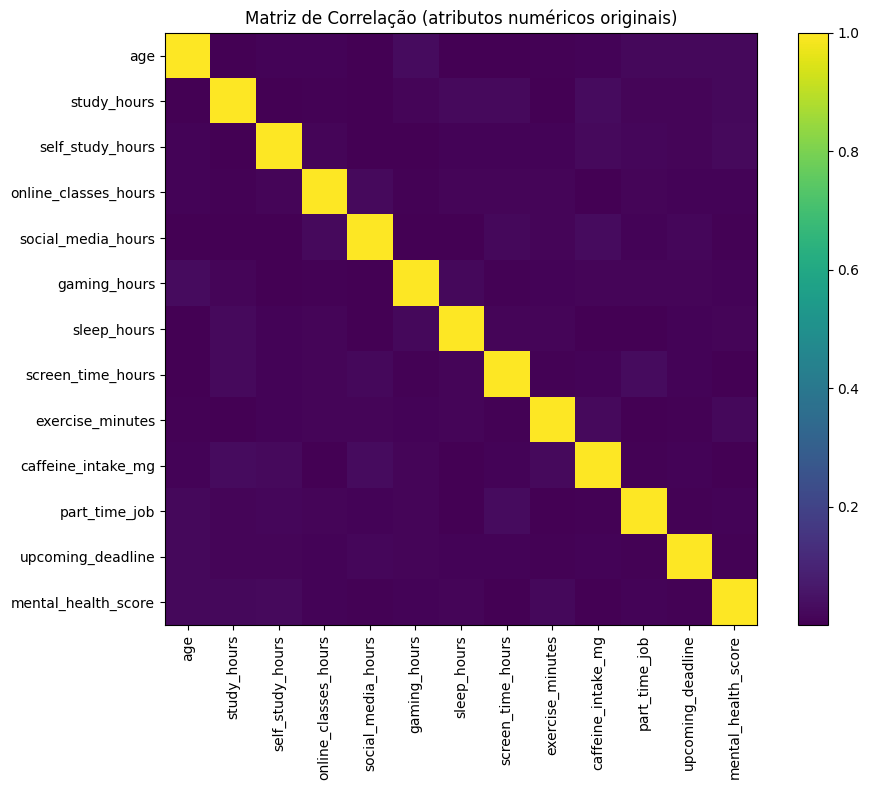

In [26]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Matriz de Correlação (atributos numéricos originais)")
plt.tight_layout()
plt.show()

A matriz de correlação revelou valores globalmente baixos entre os diferentes atributos numéricos, não sendo observadas correlações lineares fortes entre pares de variáveis. Em particular, **nenhum atributo excedeu o limiar definido de 0.90**, pelo que não foram identificadas variáveis suficientemente redundantes para justificar eliminação automática com base apenas nesta métrica.

Este resultado sugere que os atributos numéricos capturam dimensões relativamente distintas do comportamento dos estudantes, indicando baixa redundância linear no conjunto de dados.

### 1.2.2 Análise de Variância dos Atributos

Como complemento à análise de correlação, foi avaliada a variância das features com o objetivo de identificar atributos com variabilidade muito reduzida, potencialmente pouco informativos para os modelos preditivos. Features com variância próxima de zero tendem a apresentar reduzida capacidade discriminativa, uma vez que assumem valores muito semelhantes entre diferentes observações.

Ao contrário da análise de correlação, esta avaliação foi realizada **após o pré-processamento**, uma vez que pretende analisar as features efetivamente utilizadas pelos modelos, incluindo variáveis transformadas e codificadas.

Para este efeito, foi aplicado o método *Variance Threshold*, utilizando um limiar de **0.01**, removendo automaticamente atributos com variância inferior a esse valor.

A análise mostrou que **nenhuma feature apresentou variância inferior ao limiar definido**, pelo que não foram identificados atributos praticamente constantes ou com baixa variabilidade suficiente para justificar eliminação automática.

In [27]:
#por import la em cima
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.01)

var_selector.fit(X_train_df)

selected_var = feature_names[var_selector.get_support()]
removed_var = feature_names[~var_selector.get_support()]

print("Atributos removidos por baixa variância:")
print(list(removed_var))

Atributos removidos por baixa variância:
[]


Este resultado, em conjunto com a análise de correlação, indica que a redução dimensional não poderia ser sustentada apenas por critérios estatísticos simples, justificando a exploração de métodos de seleção baseados na relevância preditiva de cada atributo.

## 1.3 Métodos Testados

Como a análise estatística preliminar não identificou atributos claramente redundantes ou pouco informativos, recorreu-se a métodos de seleção baseados na relevância preditiva das features relativamente à variável-alvo.

Para esse efeito, foram avaliadas diferentes métodos complementares com critérios distintos de seleção:

- **Mutual Information:** método baseado na dependência estatística entre cada atributo e a variável-alvo, permitindo identificar features com maior capacidade informativa, incluindo relações não lineares.

- **Random Forest Feature Importance:** abordagem baseada em modelo *ensemble*, que estima a relevância relativa de cada atributo com base no seu contributo para a redução da impureza ao longo das árvores de decisão.

- **Forward Selection:** método sequencial que inicia com um conjunto vazio de atributos e adiciona iterativamente as features que produzem maior melhoria no desempenho preditivo.

- **Principal Component Analysis (PCA):** técnica de redução dimensional por transformação, que projeta os dados num novo espaço de componentes ortogonais, preservando a maior proporção possível da variância original.

Estes métodos foram avaliados separadamente para os cenários de classificação e regressão, utilizando como referência o desempenho obtido pelos modelos baseline com o conjunto completo de atributos. 

A comparação permitiu identificar o melhor compromisso entre redução dimensional, interpretabilidade e desempenho preditivo em cada problema.

## 1.4 Seleção de Atributos para Classificação

Uma vez que a análise estatística preliminar não identificou atributos claramente redundantes ou com baixa variabilidade, a seleção de atributos para o problema de classificação centrou-se em métodos orientados pela relevância preditiva relativamente à variável-alvo `high_exam_score`.

In [35]:
# =========================
# Feature Selection Comparison - Classification
# =========================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif,
    SequentialFeatureSelector,
    SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

clf = LogisticRegression(
    max_iter=2000,
    random_state=42
)

n_total_features = X_train_processed.shape[1]
n_features = min(10, n_total_features)

models = {}

# Baseline
models["Baseline"] = Pipeline([
    ("clf", clf)
])

# Mutual Information
models["Mutual Information"] = Pipeline([
    ("selector", SelectKBest(
        score_func=mutual_info_classif,
        k=n_features
    )),
    ("clf", clf)
])

# RF Importance
models["RF Feature Importance"] = Pipeline([
    ("selector", SelectFromModel(
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),
        threshold=-np.inf,
        max_features=n_features
    )),
    ("clf", clf)
])

# L1 Logistic
models["L1 Logistic"] = Pipeline([
    ("selector", SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.1,
            max_iter=2000,
            random_state=42
        )
    )),
    ("clf", clf)
])

# Forward Selection
models["Forward Selection"] = Pipeline([
    ("selector", SequentialFeatureSelector(
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),
        n_features_to_select=n_features,
        direction="forward",
        scoring="f1",
        cv=3,
        n_jobs=-1
    )),
    ("clf", clf)
])

scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Fit only L1 once to inspect adaptive feature count
models["L1 Logistic"].fit(X_train_processed, y_train_clf)
l1_selected = models["L1 Logistic"].named_steps["selector"].get_support().sum()

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train_processed,
        y_train_clf,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    if name in ["Mutual Information", "RF Feature Importance", "Forward Selection"]:
        n_selected = n_features
    elif name == "L1 Logistic":
        n_selected = l1_selected
    else:
        n_selected = n_total_features

    results.append({
        "Method": name,
        "Selected Features": n_selected,
        "F1": scores["test_f1"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results).sort_values(
    by="F1",
    ascending=False
)

display(results_df.round(4))

C:\Users\vitor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\vitor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Method,Selected Features,F1,ROC AUC
3,L1 Logistic,14,0.7210,0.9196
0,Baseline,19,0.7181,0.9197
4,Forward Selection,10,0.7173,0.9183
1,Mutual Information,10,0.6876,0.9084
2,RF Feature Importance,10,0.6731,0.9016


In [37]:
feature_names = preprocessor.get_feature_names_out()

best_forward = models["Forward Selection"]
best_forward.fit(X_train_processed, y_train_clf)

forward_selector = best_forward.named_steps["selector"]

selected_features = feature_names[forward_selector.get_support()]
removed_features = feature_names[~forward_selector.get_support()]

print("Selected features:")
print(selected_features.tolist())

print("\nRemoved features:")
print(removed_features.tolist())

Selected features:
['num__study_hours', 'num__self_study_hours', 'num__social_media_hours', 'num__gaming_hours', 'num__sleep_hours', 'num__screen_time_hours', 'num__part_time_job', 'num__upcoming_deadline', 'num__mental_health_score', 'cat__gender_Other']

Removed features:
['num__age', 'num__online_classes_hours', 'num__exercise_minutes', 'num__caffeine_intake_mg', 'cat__gender_Male', 'cat__academic_level_Postgraduate', 'cat__academic_level_Undergraduate', 'cat__internet_quality_Good', 'cat__internet_quality_Poor']


### 1.4.1 Interpretação dos resultados e justificação da escolha do método

Foram comparadas diferentes estratégias de redução dimensional e seleção de atributos para o problema de classificação, avaliando o seu impacto no desempenho preditivo através de validação cruzada estratificada, com base nas métricas **F1-score** e **ROC AUC**.

Os resultados mostram que o modelo baseline, utilizando o conjunto completo de **19 atributos**, apresentou desempenho forte (**F1 = 0.7181; ROC AUC = 0.9197**), servindo como referência para avaliar a eventual perda de informação causada pela redução dimensional.

O método **L1 Logistic (regularização L1)** apresentou o melhor F1-score (**0.7210**) com **14 atributos**, sugerindo que algumas variáveis originais são redundantes e podem ser removidas sem perda de desempenho. No entanto, a redução obtida foi relativamente moderada (**~26%**), limitando o ganho em simplicidade do modelo.

O método **Forward Selection** apresentou desempenho muito próximo do baseline (**F1 = 0.7173; ROC AUC = 0.9183**), apesar de reduzir o número de atributos de **19 para 10**, correspondendo a uma redução dimensional de aproximadamente **47%**. A análise da evolução do desempenho em função do número de atributos selecionados mostrou um crescimento rápido nas primeiras iterações, seguido de estabilização a partir de aproximadamente **8–10 atributos**, indicando que a maior parte da informação discriminativa relevante é capturada nesse intervalo e que atributos adicionais contribuem apenas marginalmente para o desempenho.

Este comportamento sugere a existência de redundância entre variáveis, uma vez que quase metade dos atributos pode ser removida sem degradação relevante do desempenho preditivo. Assim, o **Forward Selection** demonstrou um equilíbrio particularmente favorável entre simplicidade e capacidade preditiva, permitindo reduzir a complexidade do modelo sem perda prática de desempenho.

O método baseado em **Mutual Information** apresentou desempenho inferior (**F1 = 0.6837**), sugerindo que a avaliação individual da relevância estatística de cada atributo pode não capturar adequadamente interações relevantes entre variáveis no contexto deste problema.

Embora a seleção baseada em **Random Forest Feature Importance** tenha apresentado desempenho inferior quando limitada a **10 atributos** (**F1 = 0.6731**), uma análise exploratória indicou que este método necessita de um subconjunto maior (**~13–14 atributos**) para atingir desempenho comparável ao baseline, sugerindo menor eficiência na redução dimensional face ao **Forward Selection**.

O **PCA** não foi privilegiado neste problema, dado que a análise com **Variance Threshold** já sugeria que a variância dos atributos, por si só, não era um critério discriminativo útil. Isto foi corroborado pelo facto de o PCA necessitar de **18 componentes** para preservar **95% da variância**, indicando reduzida capacidade de compressão. Por esse motivo, foram priorizados métodos de seleção baseados no desempenho preditivo.

Face a estes resultados, o **Forward Selection** foi selecionado como método final de redução dimensional para o problema de classificação, por oferecer o melhor compromisso entre:

- **redução do número de atributos**
- **identificação de redundância entre variáveis**
- **manutenção do desempenho preditivo**
- **maior simplicidade e interpretabilidade do modelo final**


 [sfds](#462-coeficientes-regressao-logistica)